<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos UCB1 y UCB2

*Description:* El estudio compara el rendimiento de algoritmos UCB1 y UCB2 en un problema de k-armed bandit.
Se generan gráficas diversas para cada algoritmo.


## Preparación del entorno


Este código detecta si el notebook se está ejecutando en Google Colab o en un entorno local (VSCode/Jupyter), y en caso de estar en Colab, clona el repositorio, instala las dependencias necesarias y configura el entorno para permitir la ejecución correcta del código.

In [ ]:
# Detectar si estamos en Google Colab
import sys

if "google.colab" in sys.modules:
    print("Ejecutando en Google Colab, clonando repositorio y configurando entorno...")
    !git clone --quiet https://github.com/aalonsopuig/k_brazos_AAPGAG.git
    %cd k_brazos_AAPGAG

# Instalar dependencias en cualquier entorno (Colab o VSCode/Jupyter)
!pip install -r requirements.txt

# Agregar el directorio src al path de Python para permitir importaciones
sys.path.append("src")  
print("Directorio src añadido a sys.path:")
print(sys.path)  # Verificar que se ha añadido correctamente

Directorio src añadido a sys.path:
['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\Py


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\aalon\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#@title Importamos todas las clases y funciones
import numpy as np
from typing import List

from algorithms import Algorithm, UCB1, UCB2
from arms import ArmNormal, ArmBernoulli, ArmBinomial, ArmBeta, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos.

Este código ejecuta múltiples simulaciones de un problema de bandido k-brazos utilizando distintos algoritmos, calcula las recompensas promedio y el porcentaje de selecciones óptimas a lo largo de los pasos de tiempo

In [3]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta un experimento de multi-armed bandit para evaluar diferentes algoritmos.

    Parámetros:
    bandit: Instancia del problema Bandit, que contiene las probabilidades de recompensa de cada brazo.
    algorithms: Lista de algoritmos de selección de brazos a comparar.
    steps: Número de pasos (iteraciones) que se ejecutarán por cada corrida.
    runs: Número de veces que se repetirá el experimento para obtener promedios.

    Devuelve:
    rewards: Matriz con las recompensas promedio obtenidas por cada algoritmo en cada paso.
    optimal_selections: Matriz con el porcentaje de veces que cada algoritmo seleccionó el brazo óptimo.
    """
    
    optimal_arm = bandit.optimal_arm  # Identifica el brazo con la mejor recompensa esperada

    rewards = np.zeros((len(algorithms), steps))  # Inicializa matriz para acumular recompensas
    optimal_selections = np.zeros((len(algorithms), steps))  # Inicializa matriz para contar selecciones óptimas

    np.random.seed(seed)  # Fija la semilla para reproducibilidad

    for run in range(runs):  # Itera por cada corrida del experimento
        current_bandit = Bandit(arms=bandit.arms)  # Crea una nueva instancia del bandit para cada corrida

        for algo in algorithms:
            algo.reset()  # Reinicia el estado de cada algoritmo

        for step in range(steps):  # Itera por cada paso dentro de una corrida
            for idx, algo in enumerate(algorithms):  # Itera por cada algoritmo
                chosen_arm = algo.select_arm()  # El algoritmo selecciona un brazo
                reward = current_bandit.pull_arm(chosen_arm)  # Se obtiene la recompensa al tirar de ese brazo
                algo.update(chosen_arm, reward)  # El algoritmo actualiza su estrategia con el nuevo dato

                rewards[idx, step] += reward  # Acumula la recompensa obtenida en este paso para este algoritmo

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs  # Calcula el promedio de recompensas por cada paso y algoritmo
    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje

    return rewards, optimal_selections  # Devuelve las matrices de recompensas y selecciones óptimas

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución seleccionada (**Binomial** por defecto). Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 2 algoritmos UCB (UCB1 y UCB2)

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

Aunque todo el estudio está basado en bandidos de **distribución Binomial**, están implementadas también las **distribuciones Normal, Bernoulli, y Beta**. Para usarlas en este experimento tan solo hay que quitar la almohadilla (#) de la que se desee ejecutar a continuación.

In [5]:
# Creación del bandit
#bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
#bandit = Bandit(arms=ArmBernoulli.generate_arms(k))  # Crear un bandido con k brazos de distribución Bernoulli
bandit = Bandit(arms=ArmBinomial.generate_arms(k))  # Crear un bandido con k brazos de distribución Binomial
#bandit = Bandit(arms=ArmBeta.generate_arms(k))  # Crear un bandido con k brazos de distribución Beta
print(bandit)

Bandit with 10 arms: ArmBinomial(n=7, p=0.74), ArmBinomial(n=8, p=0.58), ArmBinomial(n=7, p=0.46), ArmBinomial(n=7, p=0.15), ArmBinomial(n=8, p=0.37), ArmBinomial(n=8, p=0.67), ArmBinomial(n=6, p=0.15), ArmBinomial(n=8, p=0.77), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.59)


In [6]:

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definimos los algoritmos a comparar: UCB1 y UCB2.
# Ambos métodos pertenecen a la familia de políticas de "Límites Superiores de Confianza" (UCB),
# que buscan equilibrar la exploración y la explotación garantizando una selección optimista
# de los brazos basada en intervalos de confianza.
#
# Elección de parámetros:
# - c = 1 en UCB1: Este parámetro ajusta la magnitud del término de exploración en la ecuación:
#   UCB1(a) = Q(a) + c * sqrt( (2 ln t) / N(a) )
#   Un valor de c=1 es comúnmente utilizado en la literatura, ya que ofrece un buen balance entre
#   exploración (buscar nuevos brazos) y explotación (aprovechar los mejores brazos identificados).
#   Valores mayores incentivan más exploración, mientras que valores menores favorecen la explotación.
#
# - α (alpha) = 0.1 en UCB2: Este parámetro controla la tasa de exploración en UCB2 mediante
#   la ecuación:
#   UCB2(a) = Q(a) + sqrt( (1+alpha) ln(e*t / τ(k_a)) / (2τ(k_a)) )
#   Donde τ(k_a) determina la cantidad de veces que se seleccionará una acción en una "época".
#   Valores pequeños de alpha (ej., 0.1) hacen que el algoritmo actúe de forma más conservadora,
#   priorizando la explotación, mientras que valores más grandes promueven más exploración.
#   Se ha elegido 0.1 como equilibrio razonable basado en estudios empíricos.
algorithms = [UCB1(k=k, c=1), UCB2(k=k, alpha=0.1)]


# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 7 with expected reward=6.16


## Visualización de los resultados

### Recompensa Promedio vs Pasos de Tiempo.
Muestra cómo evolucionan las recompensas promedio obtenidas por cada algoritmo a lo largo de los pasos de tiempo.

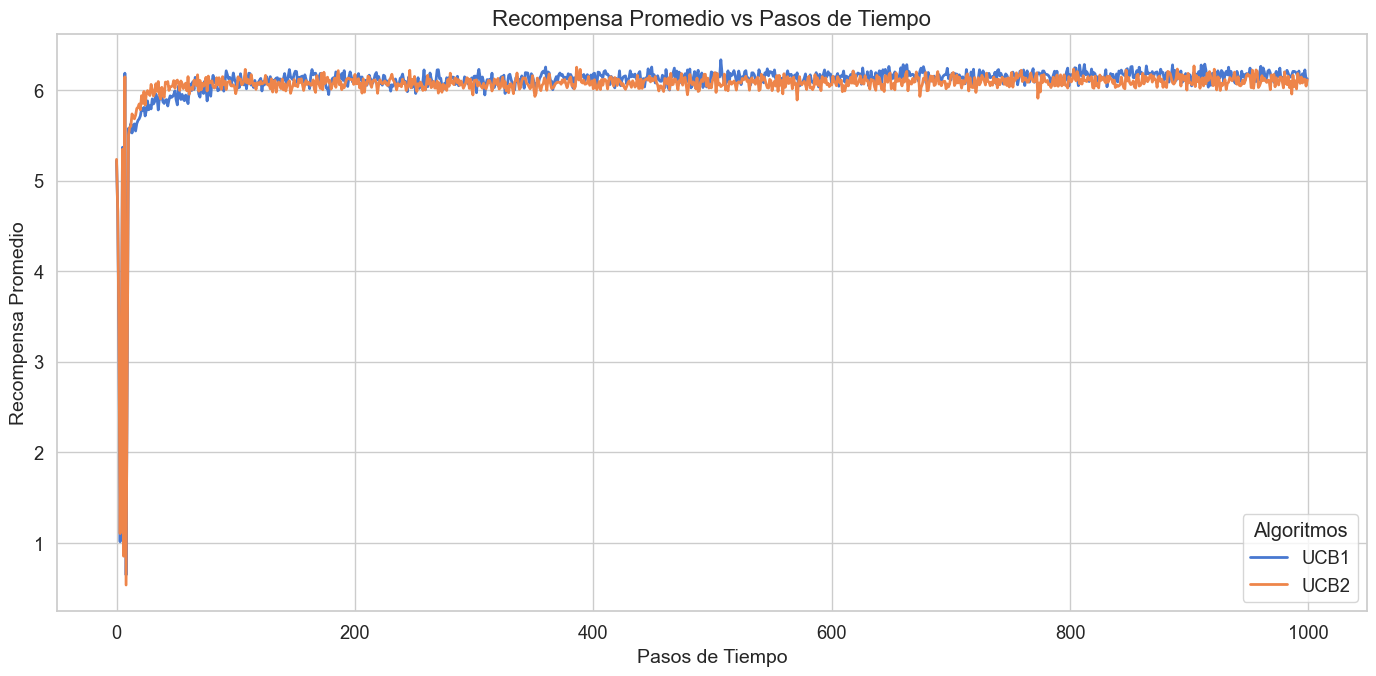

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)  # Recompensa promedio a lo largo del tiempo

#### Análisis de las gráficas

- **Inicio (0-100 pasos):** UCB2 obtiene una recompensa ligeramente mayor que UCB1, indicando que explora de manera más eficiente al principio.   
- **Estabilización (>100 pasos):** Ambos algoritmos convergen a recompensas promedio similares (~6.1 - 6.2).  
- **Influencia de la Distribución Binomial:** La discreción de la distribución hace que ambos algoritmos converjan rápidamente a valores estables.  
- **Conclusión:** UCB2 es mejor en la exploración temprana, mientras que UCB1 es más estable a largo plazo. Ambos tienen rendimientos similares en el horizonte final.

### Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo.
Esta métrica indica cuántas veces los algoritmos seleccionan el mejor brazo disponible.

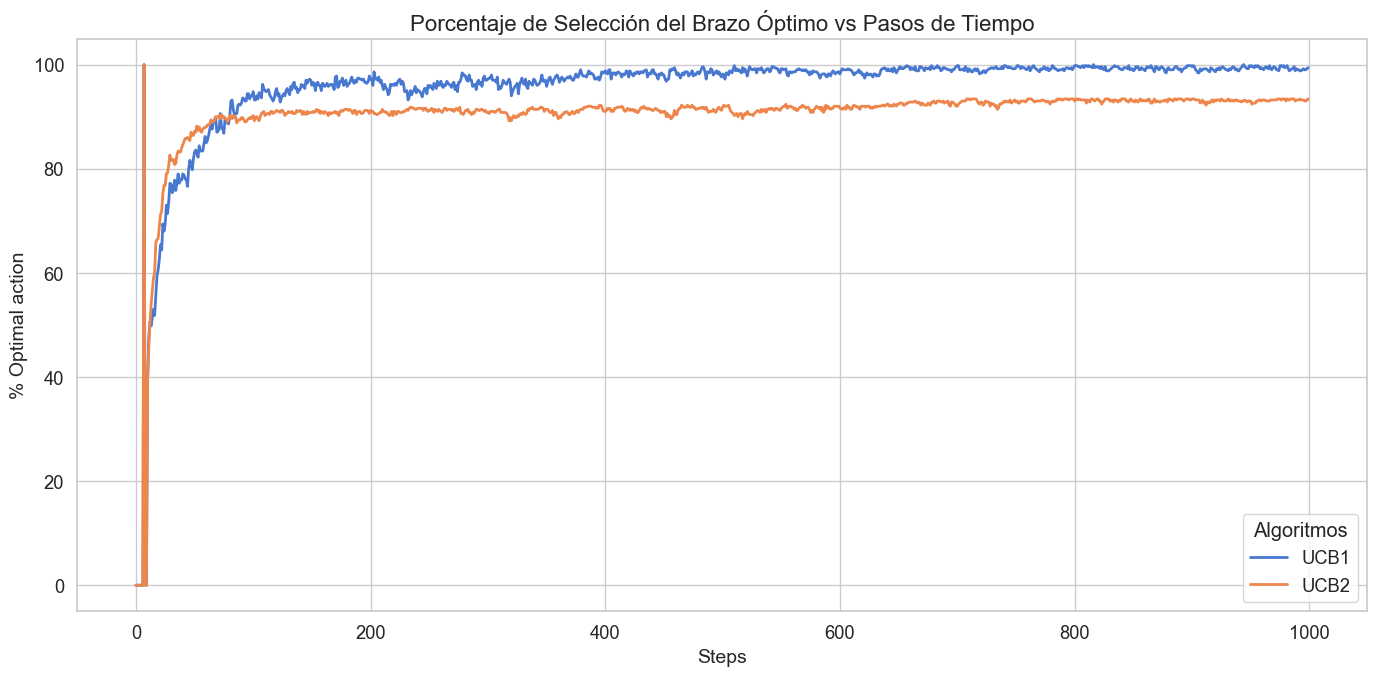

In [8]:
# Graficar la selección del brazo óptimo a lo largo del tiempo
plot_optimal_selections(steps, optimal_selections, algorithms)


#### Análisis de las gráficas

- **Fase Inicial (0-100 pasos):** UCB2 tiene un mejor desempeño en la exploración inicial, alcanzando más rápido un porcentaje alto de selección del brazo óptimo (~90%).  
- **Fase Intermedia (>100 pasos):** UCB1 supera a UCB2 en la tasa de selección óptima, alcanzando valores cercanos al 99% mientras que UCB2 se mantiene alrededor del 91-93%.  
- **Estabilización (>500 pasos):** UCB1 mantiene un porcentaje muy alto (~99%), mientras que UCB2 se estabiliza en un nivel más bajo (~93%), indicando que UCB1 converge mejor a la acción óptima.  
- **Conclusión:** UCB2 es más eficiente explorando al inicio, pero UCB1 tiene un mejor desempeño a largo plazo, asegurando más consistencia en la selección del brazo óptimo.


### Estadísticas de cada brazo

Cada valor en el eje X representará un brazo. En el eje Y se representa el promedio de las ganancias de cada brazo. El gráfico mostrará un histograma para cada brazo donde se muestre el promedio de las ganancias obtenidas pero en el eje X, como etiqueta, se mostrará también el número de veces que fue seleccionado el brazo e indicar si es el brazo óptimo o no (estrella dorada).

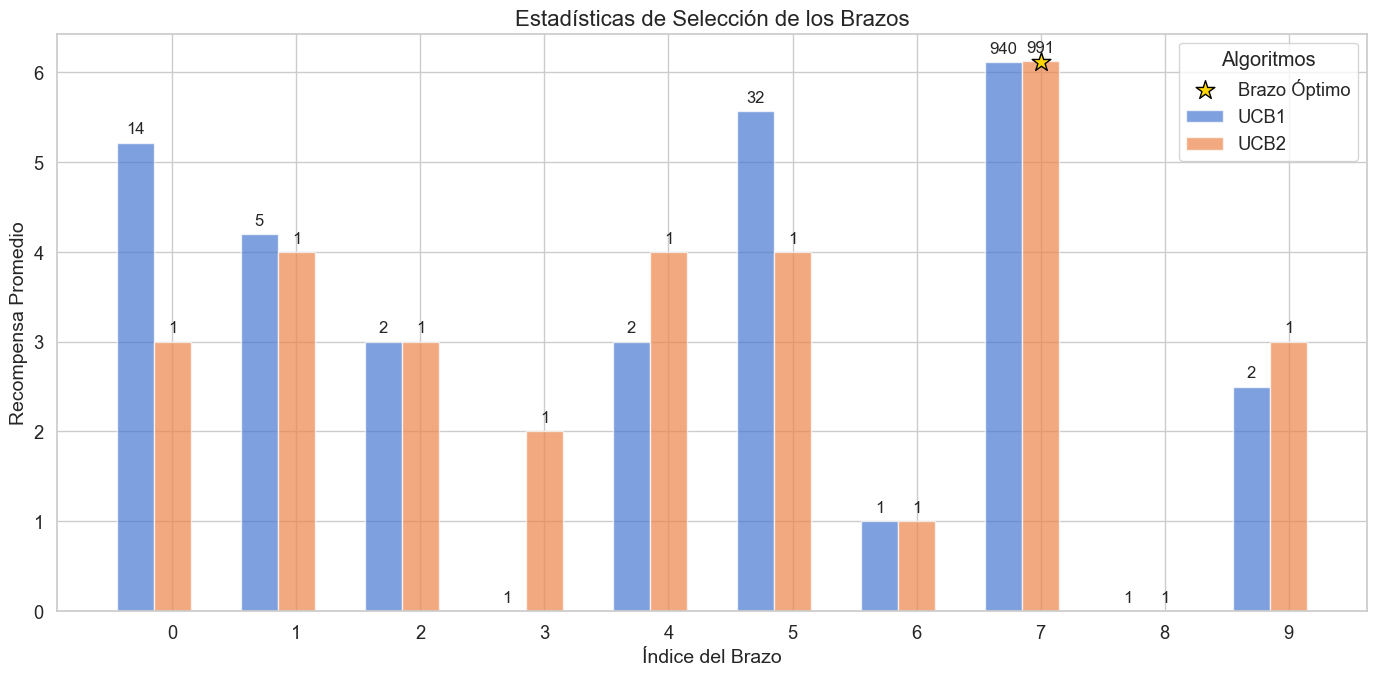

In [9]:
# Preparar los datos para la gráfica de estadísticas de brazos
arm_stats = []
for algo in algorithms:
    stats = {
        "means": algo.values,  # Recompensa promedio estimada por cada brazo
        "counts": algo.counts   # Número de veces que se seleccionó cada brazo
    }
    arm_stats.append(stats)

# Graficar estadísticas de los brazos, pasando el índice del brazo óptimo
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


#### Análisis de las gráficas



- **Brazo óptimo (índice 7):** Ambos algoritmos identifican correctamente el brazo óptimo, con UCB2 seleccionándolo **991 veces** y UCB1 **940 veces**, reflejando la preferencia de UCB2 por este brazo en el largo plazo.
- **Distribución de selecciones:** UCB1 explora más inicialmente, asignando más selecciones a otros brazos (como los brazos 0 y 5), mientras que UCB2 se concentra rápidamente en el brazo óptimo, seleccionando los demás con menor frecuencia.
- **Recompensas promedio:** En general, los brazos con mayor número de selecciones presentan una recompensa promedio más alta, lo que confirma que ambos algoritmos aprenden correctamente a priorizar los brazos más rentables.
- **Conclusión:** UCB2 converge más rápido al brazo óptimo con menor exploración adicional, mientras que UCB1 distribuye más sus selecciones antes de estabilizarse en la mejor opción.

### Evolución del rechazo

Muestra la evolución del rechazo, de forma análoga a cómo se muestra la evolución de las recompensas.

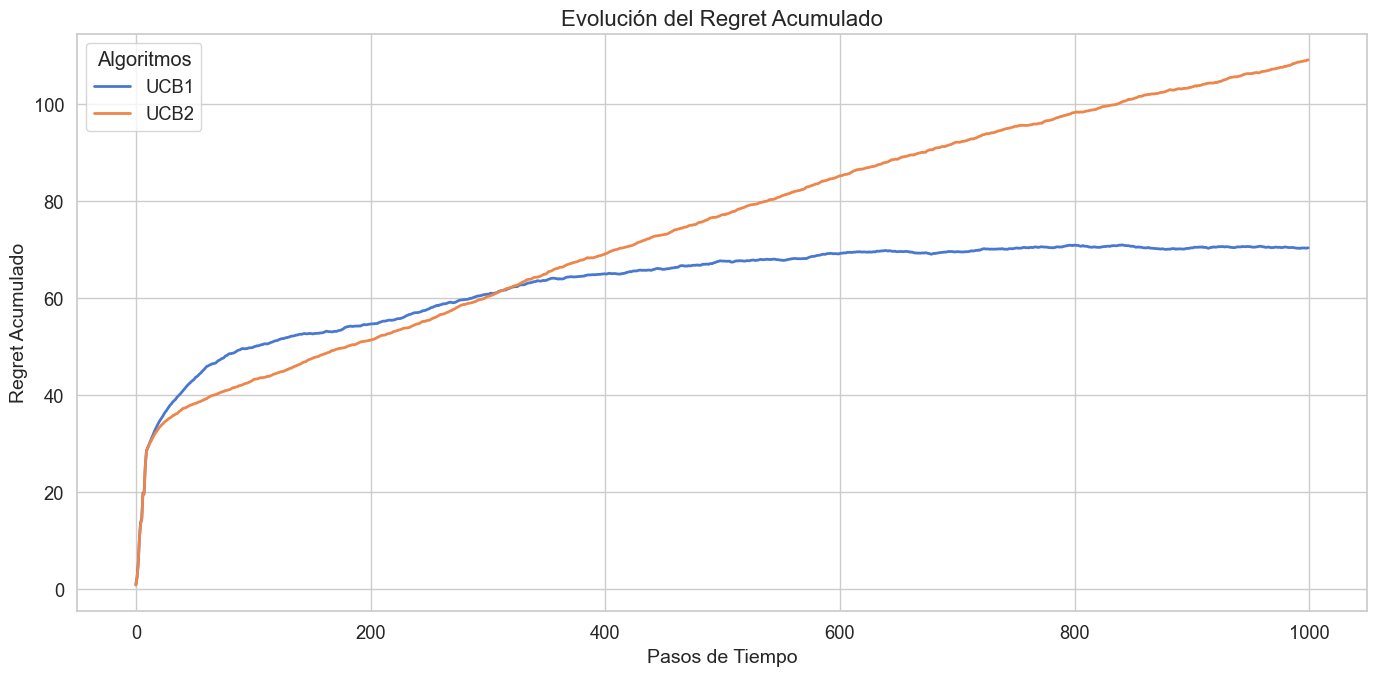

In [10]:
# Calcular el regret acumulado
optimal_reward = bandit.get_expected_value(optimal_arm)
regret_accumulated = np.cumsum(optimal_reward - rewards, axis=1)  # Regret acumulado por algoritmo

# Graficar la evolución del regret acumulado
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis de las gráficas



- **Tendencia general:** UCB1 alcanza un regret más bajo y se estabiliza, mientras que UCB2 sigue acumulando regret de manera constante.  
- **Motivo:** UCB1 explora más al principio, pero una vez identifica el mejor brazo, reduce la exploración y se enfoca en explotar. UCB2, aunque encuentra rápido el óptimo, sigue explorando periódicamente debido a su estrategia basada en épocas, lo que aumenta su regret a largo plazo.  
- **Conclusión:** UCB1 es más eficiente en minimizar el regret acumulado, mientras que UCB2 sacrifica rendimiento a largo plazo en favor de una exploración más estructurada.

# Conclusión final

Para este problema con distribución binomial, UCB1 se muestra como la opción superior al alcanzar una mayor recompensa promedio, seleccionar más veces el brazo óptimo y mantener un regret más bajo. UCB2, aunque garantiza una exploración estructurada y un balance más controlado, introduce un costo mayor en regret y menor eficiencia en la explotación del mejor brazo.

# Generación temporal de CSVs

In [11]:
algoritmo = "ucb"
from utils.experiment_data_saver import ExperimentDataSaver

# Construir etiquetas de los algoritmos basadas en sus parámetros específicos (c para UCB1 y alpha para UCB2)
algorithm_labels = [
    f"UCB1 (c={algo.c})" if isinstance(algo, UCB1) else 
    f"UCB2 (alpha={algo.alpha})" if isinstance(algo, UCB2) else 
    f"{type(algo).__name__}" 
    for algo in algorithms
]

# Crear el objeto para gestionar los archivos del experimento
data_saver = ExperimentDataSaver(algoritmo, algorithm_labels)

# Guardar los archivos CSV con los datos del experimento
data_saver.save_data(rewards, "rewards")  # Recompensa promedio
data_saver.save_data(optimal_selections, "optimal_selections")  # Selección del brazo óptimo
data_saver.save_data(regret_accumulated, "regret")  # Evolución del regret acumulado
data_saver.save_data(arm_stats, "arm_statistics", is_arm_statistics=True)  # Estadísticas de cada brazo


Archivo guardado: data/ucb_rewards_sampled.csv
Archivo guardado: data/ucb_optimal_selections_sampled.csv
Archivo guardado: data/ucb_regret_sampled.csv
Archivo guardado: data/ucb_arm_statistics_sampled.csv
